In [10]:
import json
import numpy as np
import pandas as pd
from collections import defaultdict
import matplotlib.pyplot as plt

In [11]:
# Load
groups = defaultdict(list)
with open("/home/tischuet/zero-shot-deepfake-detection/outputs/vit_large_patch14_clip_quickgelu_224_metaclip_400m/vit_large_patch14_clip_quickgelu_224_metaclip_400m_last_layer_ForenSynths.jsonl") as f:
    next(f)
    for line in f:
        entry = json.loads(line)
        groups[entry["label"]].append(np.array(entry["svdvals"]))

# Stack each label's runs into a matrix (n_entries x n_singular_values)
matrices = {label: np.vstack(runs) for label, runs in groups.items()}

In [3]:
total = sum(len(runs) for runs in groups.values())
print(f"Total entries: {total}")

Total entries: 90329


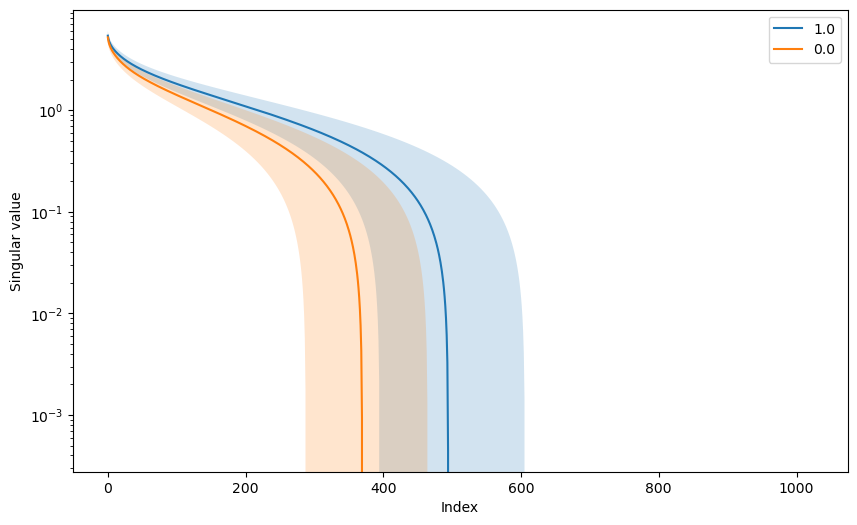

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
for label, M in matrices.items():
    idx = np.arange(M.shape[1])
    mean = M.mean(axis=0)
    std = M.std(axis=0)
    ax.plot(idx, mean, label=label)
    ax.fill_between(idx, mean - std, mean + std, alpha=0.2)

ax.set_yscale("log")  # SVD spectra usually span orders of magnitude
ax.set_xlabel("Index")
ax.set_ylabel("Singular value")
ax.legend()
plt.show()

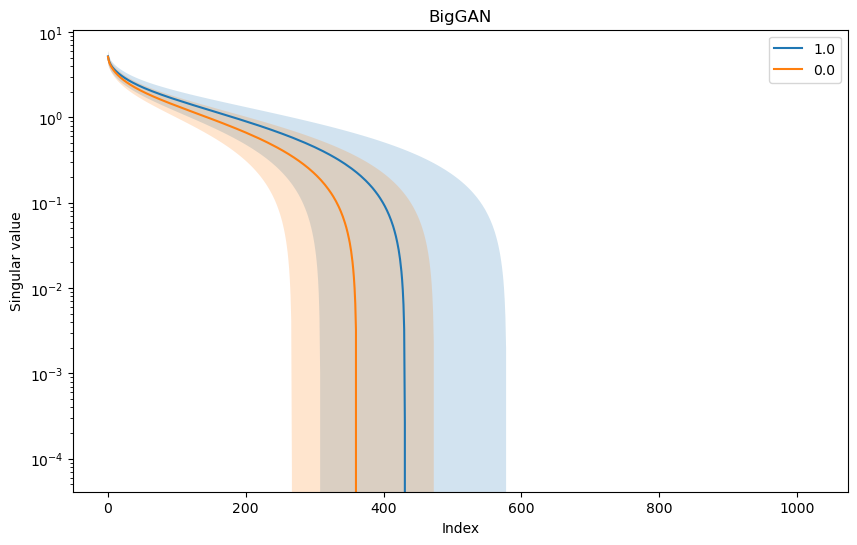

In [16]:
groups = defaultdict(list)
with open("/home/tischuet/zero-shot-deepfake-detection/outputs/vit_large_patch14_clip_quickgelu_224_metaclip_400m/vit_large_patch14_clip_quickgelu_224_metaclip_400m_last_layer_ForenSynths.jsonl") as f:
    next(f)
    for line in f:
        entry = json.loads(line)
        if "biggan" in entry["img_path"].lower():
            groups[entry["label"]].append(np.array(entry["svdvals"]))

matrices = {label: np.vstack(runs) for label, runs in groups.items()}

fig, ax = plt.subplots(figsize=(10, 6))
for label, M in matrices.items():
    idx = np.arange(M.shape[1])
    mean = M.mean(axis=0)
    std = M.std(axis=0)
    ax.plot(idx, mean, label=label)
    ax.fill_between(idx, mean - std, mean + std, alpha=0.2)

ax.set_yscale("log")
ax.set_xlabel("Index")
ax.set_ylabel("Singular value")
ax.set_title("BigGAN")
ax.legend()
plt.show()

groups basiert auf einer Selektion aus vorheriger Zelle. Analyse ist broken

In [17]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, average_precision_score


# ---------- per-entry signals ----------
# Each takes a 1D array of singular values (descending) and returns a scalar.
# Convention: higher score should predict label 1.0 (real). We flip signs
# at evaluation time if a signal is anti-correlated.

def effective_rank(s, rel_thresh=1e-6):
    s = np.asarray(s)
    return float((s > s.max() * rel_thresh).sum())

def participation_ratio(s):
    s2 = np.asarray(s) ** 2
    return float(s2.sum() ** 2 / (s2 ** 2).sum())

def stable_rank(s):
    s2 = np.asarray(s) ** 2
    return float(s2.sum() / s2.max())

def spectral_entropy(s):
    s2 = np.asarray(s) ** 2
    p = s2 / s2.sum()
    return float(-np.sum(p * np.log(p + 1e-12)))

def energy_rank(s, frac=0.9):
    s2 = np.asarray(s) ** 2
    cum = np.cumsum(s2) / s2.sum()
    return float(np.searchsorted(cum, frac))

def log_volume_topk(s, k=50):
    s = np.asarray(s)[:k]
    return float(np.log(s + 1e-12).sum())

def tail_energy_fraction(s, frac=0.25):
    s2 = np.asarray(s) ** 2
    start = int(len(s2) * (1 - frac))
    return float(s2[start:].sum() / s2.sum())

def _safe_loglog_slope(x_idx, s_slice):
    """Fit log(s) ~ a + b*log(idx), return -b. Returns NaN if ill-conditioned."""
    y = np.log(np.asarray(s_slice) + 1e-12)
    x = np.log(np.asarray(x_idx))
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 5 or np.ptp(y[mask]) < 1e-9:
        return np.nan
    try:
        coef = np.polyfit(x[mask], y[mask], 1)
        return float(-coef[0])
    except np.linalg.LinAlgError:
        return np.nan

def decay_exponent(s, lo=10, hi=200):
    s = np.asarray(s)
    hi = min(hi, len(s))
    if hi - lo < 5:
        return np.nan
    return _safe_loglog_slope(np.arange(lo, hi), s[lo:hi])

def tail_slope(s, lo_frac=0.5, hi_frac=0.9):
    s = np.asarray(s)
    n = len(s)
    lo, hi = int(n * lo_frac), int(n * hi_frac)
    if hi - lo < 5:
        return np.nan
    y = np.log(s[lo:hi] + 1e-12)
    x = np.arange(lo, hi)
    mask = np.isfinite(y) & (s[lo:hi] > 0)
    if mask.sum() < 5 or np.ptp(y[mask]) < 1e-9:
        return np.nan
    try:
        return float(-np.polyfit(x[mask], y[mask], 1)[0])
    except np.linalg.LinAlgError:
        return np.nan

def top_to_mid_ratio(s, mid_k=100):
    s = np.asarray(s)
    if len(s) <= mid_k:
        return np.nan
    return float(s[0] / (s[mid_k] + 1e-12))

def rank_over_entropy(s, rel_thresh=1e-6):
    return effective_rank(s, rel_thresh) / (spectral_entropy(s) + 1e-12)

def condition_number(s):
    s = np.asarray(s)
    s_min = s[s > s.max() * 1e-6]  # ignore numerically zero singular values
    if len(s_min) == 0:
        return np.nan
    return float(s.max() / s_min.min())

def log_condition_number(s):
    s = np.asarray(s)
    s_min = s[s > s.max() * 1e-6]
    if len(s_min) == 0:
        return np.nan
    return float(np.log(s.max()) - np.log(s_min.min()))


SIGNALS = {
    "effective_rank": effective_rank,
    "participation_ratio": participation_ratio,
    "stable_rank": stable_rank,
    "spectral_entropy": spectral_entropy,
    "energy_rank_90": lambda s: energy_rank(s, 0.9),
    "energy_rank_99": lambda s: energy_rank(s, 0.99),
    "log_volume_top50": lambda s: log_volume_topk(s, 50),
    "log_volume_top200": lambda s: log_volume_topk(s, 200),
    "tail_energy_25pct": lambda s: tail_energy_fraction(s, 0.25),
    "tail_energy_50pct": lambda s: tail_energy_fraction(s, 0.50),
    "decay_exponent": decay_exponent,
    "tail_slope": tail_slope,
    "top_to_mid_ratio": top_to_mid_ratio,
    "rank_over_entropy": rank_over_entropy,
    "condition_number": condition_number,
    "log_condition_number": log_condition_number,
}


# ---------- evaluation ----------
def evaluate_signals(groups, signals=SIGNALS, positive_label=1.0):
    """
    groups: dict {label: list of 1D singular-value arrays}
    Returns DataFrame with AUC and AP per signal. AUC reported is max of
    (auc, 1-auc) so direction doesn't matter; 'direction' column tells you
    which way the signal points.
    """
    rows = []
    for name, fn in signals.items():
        y_true, y_score = [], []
        for label, runs in groups.items():
            for s in runs:
                val = fn(s)
                if np.isfinite(val):
                    y_true.append(label)
                    y_score.append(val)
        y_true = np.array(y_true)
        y_score = np.array(y_score)

        auc_raw = roc_auc_score(y_true == positive_label, y_score)
        if auc_raw >= 0.5:
            auc, ap, direction = auc_raw, average_precision_score(y_true == positive_label, y_score), "higher=real"
        else:
            auc = 1 - auc_raw
            ap = average_precision_score(y_true == positive_label, -y_score)
            direction = "lower=real"
        rows.append({"signal": name, "AUC": auc, "AP": ap, "direction": direction})

    return pd.DataFrame(rows).sort_values("AUC", ascending=False).reset_index(drop=True)


results = evaluate_signals(groups, positive_label=1.0)
print(results.to_string(index=False))

/tmp/ipykernel_4127358/2295512911.py:35: RuntimeWarning: invalid value encountered in log
  return float(np.log(s + 1e-12).sum())
/tmp/ipykernel_4127358/2295512911.py:44: RuntimeWarning: invalid value encountered in log
  y = np.log(np.asarray(s_slice) + 1e-12)
/tmp/ipykernel_4127358/2295512911.py:68: RuntimeWarning: invalid value encountered in log
  y = np.log(s[lo:hi] + 1e-12)


              signal      AUC       AP   direction
      decay_exponent 0.674597 0.693860  lower=real
    top_to_mid_ratio 0.674401 0.675720  lower=real
      effective_rank 0.664089 0.693941 higher=real
   rank_over_entropy 0.661363 0.692168 higher=real
   log_volume_top200 0.659735 0.688063 higher=real
   tail_energy_50pct 0.651810 0.688959  lower=real
   tail_energy_25pct 0.648104 0.687328  lower=real
      energy_rank_90 0.646379 0.685151  lower=real
    log_volume_top50 0.631182 0.651515 higher=real
    spectral_entropy 0.626669 0.639143  lower=real
          tail_slope 0.611206 0.854563  lower=real
 participation_ratio 0.592553 0.575115  lower=real
      energy_rank_99 0.554582 0.551348  lower=real
    condition_number 0.540287 0.527233 higher=real
log_condition_number 0.540287 0.527233 higher=real
         stable_rank 0.512698 0.504148  lower=real


In [6]:
SIGNALS = {
    "effective_rank": effective_rank,
    "decay_exponent": decay_exponent,
}

In [8]:
import json
import numpy as np
import pandas as pd

JSONL_PATH = "/home/tischuet/zero-shot-deepfake-detection/outputs/vit_large_patch14_clip_quickgelu_224_metaclip_400m/vit_large_patch14_clip_quickgelu_224_metaclip_400m_last_layer_ForenSynths.jsonl"

# load
records = []
with open(JSONL_PATH) as f:
    for line in f:
        obj = json.loads(line.strip())
        if obj.get("_meta"):
            continue
        records.append(obj)

df = pd.DataFrame(records)
df["generator"] = df["img_path"].str.split("/").str[0]

per_gen = {}

for g, group in df[df["label"] == 1].groupby("generator"):
    real_g = df[(df["label"] == 0) & (df["generator"] == g)]
    
    if real_g.empty or group.empty:
        continue

    real_spectra = [np.exp(np.array(x)) for x in real_g["svdvals"]]
    fake_spectra = [np.exp(np.array(x)) for x in group["svdvals"]]

    groups = {0.0: real_spectra, 1.0: fake_spectra}
    result = evaluate_signals(groups, signals=SIGNALS, positive_label=1.0)
    per_gen[g] = result.set_index("signal")["AUC"]

results = pd.DataFrame(per_gen).T.sort_index()
results["macro_AUC"] = results.mean(axis=1)
print(results.round(3).to_string())

signal           decay_exponent  effective_rank  macro_AUC
biggan                    0.532             0.5      0.516
crn                       0.769             0.5      0.635
cyclegan                  0.659             0.5      0.579
deepfake                  0.607             0.5      0.553
gaugan                    0.573             0.5      0.537
imle                      0.563             0.5      0.531
progan                    0.672             0.5      0.586
san                       0.583             0.5      0.542
seeingdark                0.571             0.5      0.535
stargan                   0.634             0.5      0.567
stylegan                  0.506             0.5      0.503
stylegan2                 0.592             0.5      0.546
whichfaceisreal           0.666             0.5      0.583


In [7]:
import numpy as np
import pandas as pd

def top_shape_stats(M):
    """Per-entry stats about the top of the spectrum."""
    sigma1 = M[:, 0]
    sigma10 = M[:, 9]   if M.shape[1] > 9   else np.full(len(M), np.nan)
    sigma50 = M[:, 49]  if M.shape[1] > 49  else np.full(len(M), np.nan)
    return {
        "sigma_1": sigma1,
        "sigma_1_over_10": sigma1 / (sigma10 + 1e-12),
        "sigma_1_over_50": sigma1 / (sigma50 + 1e-12),
        # Normalized top-10 energy fraction
        "top10_energy_frac": (M[:, :10] ** 2).sum(axis=1) / (M ** 2).sum(axis=1),
    }

for label, M in matrices.items():
    stats = top_shape_stats(M)
    print(f"\nlabel={label}")
    for name, vals in stats.items():
        v = vals[np.isfinite(vals)]
        print(f"  {name:25s} mean={v.mean():.4f}  median={np.median(v):.4f}  std={v.std():.4f}")


label=1.0
  sigma_1                   mean=5.4361  median=5.3950  std=0.7019
  sigma_1_over_10           mean=1.4118  median=1.3824  std=0.1519
  sigma_1_over_50           mean=2.2375  median=2.1955  std=0.3153
  top10_energy_frac         mean=0.1306  median=0.1299  std=0.0205

label=0.0
  sigma_1                   mean=5.2179  median=5.1697  std=0.6451
  sigma_1_over_10           mean=1.4535  median=1.4276  std=0.1522
  sigma_1_over_50           mean=2.5306  median=2.4661  std=0.4100
  top10_energy_frac         mean=0.1116  median=0.1143  std=0.0270


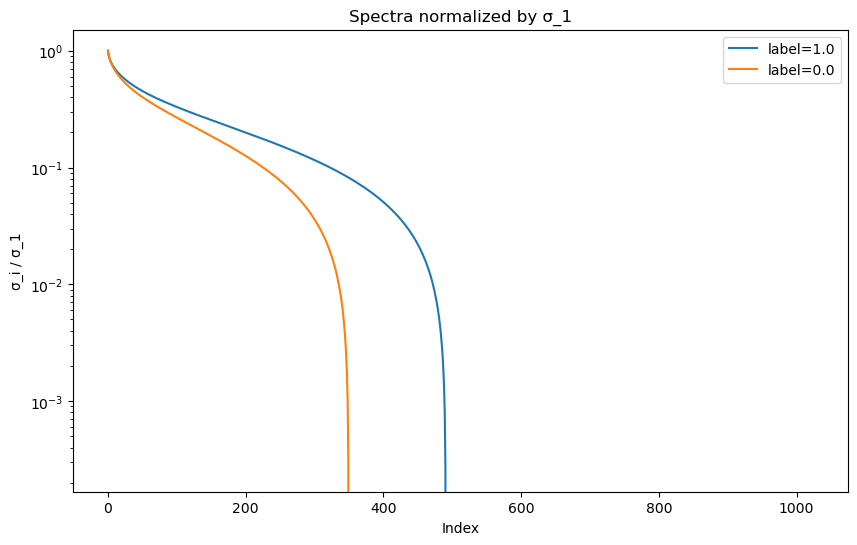

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
for label, M in matrices.items():
    M_norm = M / (M[:, :1] + 1e-12)
    mean = M_norm.mean(axis=0)
    ax.plot(mean, label=f"label={label}")
ax.set_yscale("log")
ax.set_xlabel("Index")
ax.set_ylabel("σ_i / σ_1")
ax.set_title("Spectra normalized by σ_1")
ax.legend()
plt.show()

In [9]:
from sklearn.metrics import roc_auc_score, average_precision_score

y_true, sigma1_score, sigma_sum_score = [], [], []
for label, M in matrices.items():
    y_true.extend([label] * len(M))
    sigma1_score.extend(M[:, 0].tolist())
    sigma_sum_score.extend(M.sum(axis=1).tolist())   # Frobenius-ish
y_true = np.array(y_true)

for name, score in [("sigma_1", sigma1_score), ("sigma_sum", sigma_sum_score)]:
    score = np.array(score)
    auc = roc_auc_score(y_true == 1.0, score)
    auc = max(auc, 1 - auc)
    print(f"{name}: AUC={auc:.3f}")

sigma_1: AUC=0.593
sigma_sum: AUC=0.858


In [10]:
import json

path = "/home/tischuet/zero-shot-deepfake-detection/outputs/vit_large_patch14_clip_quickgelu_224_metaclip_400m/vit_large_patch14_clip_quickgelu_224_metaclip_400m_last_layer_ForenSynths.jsonl"

with open(path) as f:
    next(f)  # skip header line
    for i, line in enumerate(f):
        entry = json.loads(line)
        print({k: (type(v).__name__ if k == "svdvals" else v) for k, v in entry.items()})
        if i >= 2:
            break

{'label': 1.0, 'score': -90.2903594971, 'img_path': 'stylegan/car/1_fake/005459.png', 'svdvals': 'list'}
{'label': 1.0, 'score': -190.5156707764, 'img_path': 'stylegan/car/1_fake/005540.png', 'svdvals': 'list'}
{'label': 1.0, 'score': 6.5352859497, 'img_path': 'stylegan/car/1_fake/005620.png', 'svdvals': 'list'}


In [11]:
import json
import numpy as np
import pandas as pd
from collections import defaultdict
from PIL import Image

PATH = "/home/tischuet/zero-shot-deepfake-detection/outputs/vit_large_patch14_clip_quickgelu_224_metaclip_400m/vit_large_patch14_clip_quickgelu_224_metaclip_400m_last_layer_ForenSynths.jsonl"

def image_stats(img):
    img = np.asarray(img, dtype=np.float32) / 255.0
    gray = img.mean(axis=-1) if img.ndim == 3 else img
    pix_std = float(gray.std())
    gy = np.diff(gray, axis=0)
    gx = np.diff(gray, axis=1)
    grad_energy = float((gy ** 2).mean() + (gx ** 2).mean())
    F = np.fft.fft2(gray - gray.mean())
    P = np.abs(F) ** 2
    h, w = P.shape
    yy, xx = np.ogrid[:h, :w]
    r = np.sqrt((yy - h // 2) ** 2 + (xx - w // 2) ** 2)
    hf_frac = float(P[r > 0.5 * r.max()].sum() / P.sum())
    return pix_std, grad_energy, hf_frac

def effective_rank(s, rel_thresh=1e-6):
    s = np.asarray(s)
    return int((s > s.max() * rel_thresh).sum())

rows = []
with open(PATH) as f:
    next(f)  # skip header
    for line in f:
        entry = json.loads(line)
        # ----- ADJUST THIS LINE based on the actual field name -----
        img_path = entry.get("image_path") or entry.get("path") or entry.get("filename")
        # -----------------------------------------------------------
        try:
            img = Image.open(img_path).convert("RGB")
            pix_std, grad_energy, hf_frac = image_stats(img)
        except Exception as e:
            pix_std = grad_energy = hf_frac = np.nan

        rows.append({
            "label": entry["label"],
            "eff_rank": effective_rank(entry["svdvals"]),
            "pix_std": pix_std,
            "grad_energy": grad_energy,
            "hf_frac": hf_frac,
        })

df = pd.DataFrame(rows)
print(df.head())
print(f"\nRows with missing image stats: {df['pix_std'].isna().sum()} / {len(df)}")

   label  eff_rank  pix_std  grad_energy  hf_frac
0    1.0       387      NaN          NaN      NaN
1    1.0       377      NaN          NaN      NaN
2    1.0       437      NaN          NaN      NaN
3    1.0       316      NaN          NaN      NaN
4    1.0       430      NaN          NaN      NaN

Rows with missing image stats: 90329 / 90329


In [12]:
from scipy.stats import spearmanr

clean = df.dropna()

print("=== Pooled correlations ===")
for col in ["pix_std", "grad_energy", "hf_frac"]:
    r, p = spearmanr(clean["eff_rank"], clean[col])
    print(f"  eff_rank vs {col:12s}  ρ={r:+.3f}  p={p:.2e}")

print("\n=== Within-class correlations ===")
for label, sub in clean.groupby("label"):
    print(f"\nlabel={label} (n={len(sub)})")
    for col in ["pix_std", "grad_energy", "hf_frac"]:
        r, p = spearmanr(sub["eff_rank"], sub[col])
        print(f"  eff_rank vs {col:12s}  ρ={r:+.3f}  p={p:.2e}")

print("\n=== Class means ===")
print(clean.groupby("label")[["eff_rank", "pix_std", "grad_energy", "hf_frac"]].mean())

=== Pooled correlations ===
  eff_rank vs pix_std       ρ=+nan  p=nan
  eff_rank vs grad_energy   ρ=+nan  p=nan
  eff_rank vs hf_frac       ρ=+nan  p=nan

=== Within-class correlations ===

=== Class means ===
Empty DataFrame
Columns: [eff_rank, pix_std, grad_energy, hf_frac]
Index: []
